<a href="https://colab.research.google.com/github/JulianPineda369/PruebaImagineApps/blob/main/Proyecto_MagicLogs_Juli%C3%A1n_Pineda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Proyecto MagicLogs Julián Pineda

In [3]:

!apt install postgresql postgresql-contrib &>log
!service postgresql start
!sudo -u postgres psql -c "CREATE USER root WITH SUPERUSER"
%load_ext sql
%sql postgresql+psycopg2://@/postgres

 * Starting PostgreSQL 14 database server
   ...done.
CREATE ROLE


## 1: Creación de tablas
Procedemos a crear las tablas, con sus correspondientes PK y FK.


In [6]:
%%sql
create table socios (
  documento BIGINT PRIMARY KEY,
  nombre VARCHAR(100),
  domicilio VARCHAR(150),
  ciudad VARCHAR(100),
  delegacion VARCHAR(100)
);

create table profesores (
  documento BIGINT PRIMARY KEY,
  nombre VARCHAR(100),
  domicilio VARCHAR(150)
);

create table cursos (
  id_curso SERIAL PRIMARY KEY,
  deporte VARCHAR(50),
  dia VARCHAR(20),
  documento_profesor BIGINT REFERENCES profesores(documento)
);

create table inscritos (
  id SERIAL PRIMARY KEY,
  documento_socio BIGINT REFERENCES socios(documento),
  id_curso INT REFERENCES cursos(id_curso),
  matricula CHAR(1),
  fecha_actualizacion TIMESTAMP
);

 * postgresql+psycopg2://@/postgres
Done.
Done.
Done.
Done.


[]

## 2: Insercion
Creadas las tablas, pasamos a hacer la inserción de la información como se solicita, indicando en qué tablas van.

In [7]:
%%sql
-- Socios
insert into socios values
(30000000, 'Fabian Fuentes', 'Caseros 987', 'Ciudad de México', 'Miguel Hidalgo'),
(31111111, 'Gaston Garcia', 'Guemes 65', 'Ciudad de México', 'Xochimilco'),
(32222222, 'Hector Huerta', 'Sucre 534', 'Ciudad de México', 'Tlalpan'),
(33333333, 'Ines Irala', 'Bulnes 345', 'Ciudad de México', 'Benito Juarez'),
(35874214, 'Rafael Capacho', 'Lago Mask 58', 'Ciudad de México', 'Miguel Hidalgo');

-- Profesores
insert into profesores values
(22222222, 'Ana Acosta', 'Avellaneda 231'),
(23333333, 'Carlos Caseres', 'Colon 245'),
(24444444, 'Reyna Sofia', 'Sarmiento 987'),
(25555555, 'Esteban Cambiaso', 'Sucre 1204');

-- Cursos (el id_curso lo genera SERIAL automáticamente)
insert into cursos (deporte, dia, documento_profesor) values
('tenis', 'lunes', 22222222),
('tenis', 'martes', 22222222),
('natacion', 'miercoles', 22222222),
('natacion', 'jueves', 23333333),
('natacion', 'viernes', 23333333),
('futbol', 'sabado', 24444444),
('futbol', 'lunes', 24444444),
('basquet', 'martes', 24444444);

-- Inscritos
insert into inscritos (documento_socio, id_curso, matricula) values
(30000000, 1, 's'),
(30000000, 3, 'n'),
(30000000, 6, NULL),
(31111111, 1, 's'),
(31111111, 4, 's'),
(32222222, 8, 's');

 * postgresql+psycopg2://@/postgres
5 rows affected.
4 rows affected.
8 rows affected.
6 rows affected.


[]

## Documentación del Esquema

Esta propuesta de base de datos está diseñada para gestionar los socios, profesores, cursos e inscripciones de un club deportivo.

---

### Tabla: socios
Almacena la información personal de cada miembro del club.
| Columna    | Tipo         | Descripción                        |
|------------|--------------|------------------------------------|
| documento  | BIGINT (PK)  | Identificador único del socio      |
| nombre     | VARCHAR(100) | Nombre completo                    |
| domicilio  | VARCHAR(150) | Dirección de residencia            |
| ciudad     | VARCHAR(100) | Ciudad de residencia               |
| delegacion | VARCHAR(100) | Delegación o municipio             |

---

### Tabla: profesores
Almacena los datos de los profesores que dictan los cursos.
| Columna   | Tipo         | Descripción                        |
|-----------|--------------|------------------------------------|
| documento | BIGINT (PK)  | Identificador único del profesor   |
| nombre    | VARCHAR(100) | Nombre completo                    |
| domicilio | VARCHAR(150) | Dirección de residencia            |

---

### Tabla: cursos
Define cada curso disponible en el club, su deporte, día y profesor asignado.
| Columna            | Tipo        | Descripción                          |
|--------------------|-------------|--------------------------------------|
| id_curso           | SERIAL (PK) | Identificador único del curso        |
| deporte            | VARCHAR(50) | Nombre del deporte                   |
| dia                | VARCHAR(20) | Día de la semana en que se dicta     |
| documento_profesor | BIGINT (FK) | Referencia al profesor que lo dicta  |

---

### Tabla: inscritos
Tabla puente que registra qué socios están inscritos en qué cursos.
| Columna             | Tipo        | Descripción                              |
|---------------------|-------------|------------------------------------------|
| id                  | SERIAL (PK) | Identificador único de la inscripción    |
| documento_socio     | BIGINT (FK) | Referencia al socio inscrito             |
| id_curso            | INT (FK)    | Referencia al curso                      |
| matricula           | CHAR(1)     | Estado: s=activo, n=inactivo, null=pend. |
| fecha_actualizacion | TIMESTAMP   | Fecha del último cambio de matrícula     |

---

### Relaciones
Se inserta modelo ER para mayor claridad en las relaciones


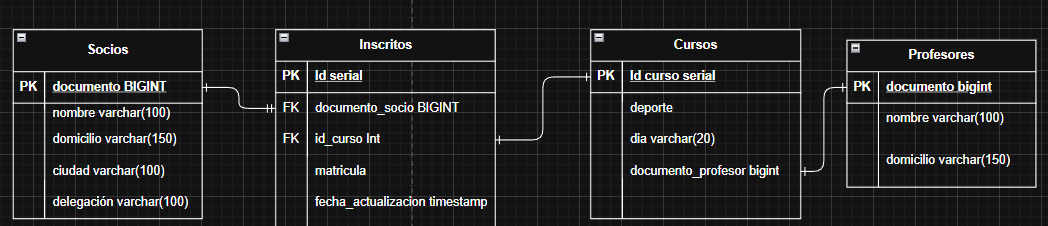

## 3: Vista de Administración
El director no quiere que el personal administrativo vea la estructura
interna de las tablas ni datos sensibles. Por eso creamos una vista:
una "ventana" con solo permisos de lectura (similar a un openquery o linked server) uniendo todo en una sola consulta:


In [8]:
%%sql
create view vista_inscripciones as
select s.nombre as socio
      ,s.documento as documento_socio
      ,c.deporte
      ,c.dia
      ,p.nombre as nombre_profesor
from inscritos i
join socios s on i.documento_socio = s.documento
join cursos c on i.id_curso = c.id_curso
join profesores p on c.documento_profesor = p.documento

 * postgresql+psycopg2://@/postgres
Done.


[]

Verificamos

In [12]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT' #Para traer la versión que deje ver la ejecución de comandos SQL

In [13]:
%%sql
select * from vista_inscripciones

 * postgresql+psycopg2://@/postgres
6 rows affected.


socio,documento_socio,deporte,dia,nombre_profesor
Fabian Fuentes,30000000,tenis,lunes,Ana Acosta
Fabian Fuentes,30000000,natacion,miercoles,Ana Acosta
Fabian Fuentes,30000000,futbol,sabado,Reyna Sofia
Gaston Garcia,31111111,tenis,lunes,Ana Acosta
Gaston Garcia,31111111,natacion,jueves,Carlos Caseres
Hector Huerta,32222222,basquet,martes,Reyna Sofia


## 4: Función para la Cantidad de inscritos por deporte

Creamos una función que recibe un deporte como parámetro
y retorna cuántos socios están inscritos en ese deporte.

In [14]:
%%sql
create or replace function inscritos_por_deporte(p_deporte VARCHAR)
returns INT language sql as $$
    select COUNT(*)::INT --Traemos cantidad en los deportes
    from inscritos i
    join cursos c ON i.id_curso = c.id_curso
    where c.deporte = p_deporte;
$$

 * postgresql+psycopg2://@/postgres
Done.


[]

Probamos con los deportes que sí están:

In [15]:
%%sql
select inscritos_por_deporte('tenis')    AS tenis,
       inscritos_por_deporte('natacion') AS natacion,
       inscritos_por_deporte('futbol')   AS futbol,
       inscritos_por_deporte('basquet')  AS basquet

 * postgresql+psycopg2://@/postgres
1 rows affected.


tenis,natacion,futbol,basquet
2,2,1,1


Con eso podemos pasar al paso 5.

## 5: Funcion de cursos sin inscritos en formato JSON

Se debe retornar un JSON con los cursos (deporte y día) que no tienen
ningún socio inscrito.

In [21]:
%%sql
create or replace function cursos_sin_inscritos()
returns JSON language sql as $$
    select json_agg(
        json_build_object(
            'deporte', deporte,
            'dia', dia
        )
    )
    from cursos
    where id_curso not in ( --Excluimos los cursos que sí tengan inscritos por id
        select distinct id_curso from inscritos
    )
$$

 * postgresql+psycopg2://@/postgres
Done.


[]

Probamos:

In [22]:
%%sql
SELECT cursos_sin_inscritos();

 * postgresql+psycopg2://@/postgres
1 rows affected.


cursos_sin_inscritos
"[{'deporte': 'tenis', 'dia': 'martes'}, {'deporte': 'natacion', 'dia': 'viernes'}, {'deporte': 'futbol', 'dia': 'lunes'}]"


Funciona y lo trae en el formato adecuado.

## 6: Función con Cursor: Socios sin ningún curso inscrito

Usamos un cursor explícito para recorrer fila por fila los socios
que no aparecen en la tabla inscritos como lo pide la tarea. A diferencia del Paso 5, aquí usamos PL/pgSQL (no SQL puro) porque necesitamos lógica
procedural: abrir cursor, iterar, acumular resultados y cerrar.

In [24]:
%%sql
create or replace function socios_sin_cursos()
returns json language plpgsql as $$
declare
    cur cursor for -- consulta que voy a recorrer
        select documento, nombre
        from socios
        where documento not in (
            select distinct documento_socio from inscritos
        );
    rec  record;
    arr  json[] := '{}';
begin
    open cur; -- abro la consulta y pongo el cursor al inicio
    loop
        fetch cur into rec; -- adjunta una línea y sigue el proceso
        exit when not found;
        arr := arr || json_build_object(
            'documento', rec.documento,
            'nombre',    rec.nombre
        )::json;
    end loop;
    close cur; -- cierra el bucle
    return array_to_json(arr);
end;
$$;

 * postgresql+psycopg2://@/postgres
Done.


[]

Probamos:

In [25]:
%%sql
select * from socios_sin_cursos()

 * postgresql+psycopg2://@/postgres
1 rows affected.


socios_sin_cursos
"[{'documento': 33333333, 'nombre': 'Ines Irala'}, {'documento': 35874214, 'nombre': 'Rafael Capacho'}]"


Efectivamente, lo trae iterando con plpgsql.

## 7: Trigger de log de eliminaciones en inscritos

Un trigger es un procedimiento que se ejecuta AUTOMÁTICAMENTE
cuando ocurre un evento (INSERT, UPDATE, DELETE) sobre una tabla.
Aquí registraremos con el siguiente código en una tabla de log quién fue eliminado, de qué curso y exactamente cuándo ocurrió.

In [26]:
%%sql
create table log_inscritos (
    id           serial primary key,
    nombre_socio varchar(100),
    nombre_curso varchar(50),
    fecha_hora   timestamp default now()
);

create or replace function fn_log_delete()
returns trigger language plpgsql as $$
declare
    v_socio   varchar;
    v_deporte varchar;
begin
    select nombre into v_socio
    from socios where documento = old.documento_socio;

    select deporte into v_deporte
    from cursos where id_curso = old.id_curso;

    insert into log_inscritos(nombre_socio, nombre_curso)
    values (v_socio, v_deporte);

    return old;
end;
$$;

create trigger trg_delete_inscrito
after delete on inscritos
for each row execute function fn_log_delete();

 * postgresql+psycopg2://@/postgres
Done.
Done.
Done.


[]

Probamos

In [27]:
%%sql
-- Eliminamos a Hector Huerta del basquet
DELETE FROM inscritos
WHERE documento_socio = 32222222 AND id_curso = 8;

-- Verificamos que quedó registrado en el log
SELECT * FROM log_inscritos;

 * postgresql+psycopg2://@/postgres
1 rows affected.
1 rows affected.


id,nombre_socio,nombre_curso,fecha_hora
1,Hector Huerta,basquet,2026-03-24 21:15:42.106457


Funcional.

## 8: Trigger para fecha de actualización automática

Cuando alguien modifica la columna 'matricula' en la tabla inscritos,
el trigger actualiza automáticamente la columna 'fecha_actualizacion'
con el timestamp exacto del cambio.

In [28]:
%%sql
create or replace function fn_update_matricula()
returns trigger language plpgsql as $$
begin
    if new.matricula is distinct from old.matricula then
        new.fecha_actualizacion := now();
    end if;
    return new;
end;
$$;

create trigger trg_update_matricula
before update on inscritos
for each row execute function fn_update_matricula();

 * postgresql+psycopg2://@/postgres
Done.
Done.


[]

Probamos

In [29]:
%%sql
-- Cambiamos la matrícula de Gaston Garcia
UPDATE inscritos
SET matricula = 'n'
WHERE documento_socio = 31111111 AND id_curso = 1;

-- Verificamos que se actualizó la fecha automáticamente
SELECT id, documento_socio, matricula, fecha_actualizacion
FROM inscritos
WHERE documento_socio = 31111111;

 * postgresql+psycopg2://@/postgres
1 rows affected.
2 rows affected.


id,documento_socio,matricula,fecha_actualizacion
5,31111111,s,None
4,31111111,n,2026-03-24 21:18:53.686156


En el anterior trigger solo se modifica la fecha de la actualización del evento que realmente cambió, no en todas (tampoco se elimina el registro original, por efectos de historiales).

## 9: Profesores que imparten más de un día

Hay que agrupar los cursos por profesor y luego filtrar aquellos con curso >1.

In [30]:
%%sql
select p.nombre, count(c.id_curso) as total_dias
from profesores p
join cursos c on p.documento = c.documento_profesor
group by p.documento, p.nombre
having count(c.id_curso) > 1
order by total_dias desc;

 * postgresql+psycopg2://@/postgres
3 rows affected.


nombre,total_dias
Ana Acosta,3
Reyna Sofia,3
Carlos Caseres,2


## 10: Case when de Evaluación de registros

Evaluamos cada inscrito con un CASE que verifica:
- Condición A (doc empieza en 3222): matrícula diligenciada +
  fecha_actualizacion > 3 días calendario desde hoy → 1
- Condición B (doc empieza en 3111): matrícula diligenciada +
  fecha_actualizacion > 3 días hábiles desde hoy → 1
- Cualquier otro caso → 0

In [31]:
%%sql
SELECT
    documento_socio,
    matricula,
    fecha_actualizacion,
    CASE
        -- Condición A: empieza en 3222, días calendario
        WHEN matricula IS NOT NULL
             AND fecha_actualizacion IS NOT NULL
             AND (CURRENT_DATE - fecha_actualizacion::date) > 3
             AND CAST(documento_socio AS TEXT) LIKE '3222%'
        THEN 1

        -- Condición B: empieza en 3111, días hábiles
        WHEN matricula IS NOT NULL
             AND fecha_actualizacion IS NOT NULL
             AND (
                 (CURRENT_DATE - fecha_actualizacion::date)
                 - (2 * ((CURRENT_DATE - fecha_actualizacion::date) / 7))
                 - CASE WHEN EXTRACT(DOW FROM fecha_actualizacion) = 6 THEN 1 ELSE 0 END
                 - CASE WHEN EXTRACT(DOW FROM fecha_actualizacion) = 0 THEN 1 ELSE 0 END
             ) > 3
             AND CAST(documento_socio AS TEXT) LIKE '3111%'
        THEN 1

        ELSE 0
    END AS es_correcto
FROM inscritos
ORDER BY documento_socio;

%%sql
select
    documento_socio,
    matricula,
    fecha_actualizacion,
    case
    -- Condición A: empieza en 3222, días calendario
        when matricula is not null
             and fecha_actualizacion is not null
             and (current_date - fecha_actualizacion::date) > 3
             and cast(documento_socio as text) like '3222%'
        then 1
    -- Condición B: empieza en 3111, días hábiles
        when matricula is not null
             and fecha_actualizacion is not null
             and (
                 (current_date - fecha_actualizacion::date)
                 - (2 * ((current_date - fecha_actualizacion::date) / 7))
                 - case when extract(dow from fecha_actualizacion) = 6 then 1 else 0 end
                 - case when extract(dow from fecha_actualizacion) = 0 then 1 else 0 end
             ) > 3
             and cast(documento_socio as text) like '3111%'
        then 1
        else 0
    end as es_correcto
from inscritos
order by documento_socio;

 * postgresql+psycopg2://@/postgres
5 rows affected.


documento_socio,matricula,fecha_actualizacion,es_correcto
30000000,s,None,0
30000000,n,None,0
30000000,None,None,0
31111111,s,None,0
31111111,n,2026-03-24 21:18:53.686156,0


Este código claramente no va a traer 1s, dado que por la fecha de la actualización no han pasado los tres días que impone la tarea, pero parametrizando todo, al pasar 3 días debería funcionar. Con esto, damos por finalizadas las tareas que requieren de SQL :D

##11. Análisis y corrección de DDLs
Se adjunta el DDL y las líneas donde está fallando:

In [ ]:
%%script False
CREATE TABLE profesores (
    profesor_id SERIAL PRIMARY KEY,
    nombre VARCHAR(100) NOT NULL,
    departamento VARCHAR(100)
);

CREATE TABLE clases (
    clase_id SERIAL PRIMARY KEY,
    nombre VARCHAR(100) NOT NULL,
    profesor_id INT REFERENCES profesores(profesor_id),
    horario VARCHAR(50)
);

CREATE TABLE alumnos (
    alumno_id SERIAL PRIMARY KEY,
    nombre VARCHAR(100) NOT NULL,
    email VARCHAR(150),
    clase_id INT REFERENCES clases(clase_id)
);

INSERT INTO profesores (nombre, departamento) VALUES
('Juan Pérez', 'Matemáticas'),
('Ana Gómez', 'Física');

INSERT INTO clases (nombre, profesor_id, horario) VALUES
('Álgebra', 1, 'Lunes 08:00'),
('Cálculo', 1, 'Miércoles 10:00'),
('Mecánica', 2, 'Martes 09:00');

INSERT INTO alumnos (nombre, email, clase_id) VALUES
('Carlos Ruiz', 'carlos@email.com', 1),
('María Torres', 'maria@email.com', 1),
('Luis Díaz', 'luis@email.com', 2),
('Sofía Herrera', 'sofia@email.com', 3);

CREATE OR REPLACE FUNCTION obtener_profesores_json()
RETURNS JSON
LANGUAGE sql
AS $$
SELECT json_agg(
    json_build_object(
        'profesor_id',  p.profesor_id::text,
        'nombre',       p.nombre,
        'departamento', p.departamento,
        'clases', (
            SELECT json_agg(
                json_build_object(
                    'clase_id', c.clase_id,
                    'nombre',   c.nombre,
                    'horario',  c.horario::integer,     -- Horario no puede ser entero, porque tiene formato fecha y hora.
                    'alumnos', (
                        SELECT json_agg(
                            json_build_object(
                                'alumno_id', a.alumno_id,
                                'nombre',    a.nombre,
                                'email',     a.email::integer  -- Email debe ser varchar o text, dado que tiene caracteres alfanuméricos
                            )
                        )
                        FROM alumnos a
                        WHERE a.clase_id = p.profesor_id       -- Se está juntando mal las consultas, debería ser o por clase_id o por profesor_id en ambas tablas, no mezclados.
                        GROUP BY a.clase_id                    -- Group by innecesario, porque no hay operaciones.
                    )
                )
            )
            FROM clases c
            WHERE c.profesor_id = p.profesor_id
            GROUP BY c.profesor_id                             -- Group by innecesario
        )
    )
)
FROM profesores p
GROUP BY p.profesor_id, p.nombre;                             -- Group by innecesario.
$$;

Traje igual el código corregido, para verificar. Usaré un subindice 2 para indicar nuevas tablas y no alterar las que ya tenemos. El Create e Insert estaban correctos:

In [32]:
%%sql
CREATE TABLE profesores2 (
    profesor_id SERIAL PRIMARY KEY,
    nombre VARCHAR(100) NOT NULL,
    departamento VARCHAR(100)
);

CREATE TABLE clases2 (
    clase_id SERIAL PRIMARY KEY,
    nombre VARCHAR(100) NOT NULL,
    profesor_id INT REFERENCES profesores2(profesor_id),
    horario VARCHAR(50)
);

CREATE TABLE alumnos2 (
    alumno_id SERIAL PRIMARY KEY,
    nombre VARCHAR(100) NOT NULL,
    email VARCHAR(150),
    clase_id INT REFERENCES clases2(clase_id)
);

INSERT INTO profesores2 (nombre, departamento) VALUES
('Juan Pérez', 'Matemáticas'),
('Ana Gómez', 'Física');

INSERT INTO clases2 (nombre, profesor_id, horario) VALUES
('Álgebra', 1, 'Lunes 08:00'),
('Cálculo', 1, 'Miércoles 10:00'),
('Mecánica', 2, 'Martes 09:00');

INSERT INTO alumnos2 (nombre, email, clase_id) VALUES
('Carlos Ruiz', 'carlos@email.com', 1),
('María Torres', 'maria@email.com', 1),
('Luis Díaz', 'luis@email.com', 2),
('Sofía Herrera', 'sofia@email.com', 3);

 * postgresql+psycopg2://@/postgres
Done.
Done.
Done.
2 rows affected.
3 rows affected.
4 rows affected.


[]

Se trae la función corregida:

In [33]:
%%sql
CREATE OR REPLACE FUNCTION obtener_profesores_json()
RETURNS JSON
LANGUAGE sql
AS $$
SELECT json_agg(
    json_build_object(
        'profesor_id',  p.profesor_id::text,
        'nombre',       p.nombre,
        'departamento', p.departamento,
        'clases', (
            SELECT json_agg(
                json_build_object(
                    'clase_id', c.clase_id,
                    'nombre',   c.nombre,
                    'horario',  c.horario,
                    'alumnos', (
                        SELECT json_agg(
                            json_build_object(
                                'alumno_id', a.alumno_id,
                                'nombre',    a.nombre,
                                'email',     a.email
                            )
                        )
                        FROM alumnos2 a
                        WHERE a.clase_id = c.clase_id
                    )
                )
            )
            FROM clases2 c
            WHERE c.profesor_id = p.profesor_id
        )
    )
)
FROM profesores2 p;
$$;

 * postgresql+psycopg2://@/postgres
Done.


[]

Probamos:

In [34]:
%%sql
SELECT obtener_profesores_json();

 * postgresql+psycopg2://@/postgres
1 rows affected.


obtener_profesores_json
"[{'profesor_id': '1', 'nombre': 'Juan Pérez', 'departamento': 'Matemáticas', 'clases': [{'clase_id': 1, 'nombre': 'Álgebra', 'horario': 'Lunes 08:00', 'alumnos': [{'alumno_id': 1, 'nombre': 'Carlos Ruiz', 'email': 'carlos@email.com'}, {'alumno_id': 2, 'nombre': 'María Torres', 'email': 'maria@email.com'}]}, {'clase_id': 2, 'nombre': 'Cálculo', 'horario': 'Miércoles 10:00', 'alumnos': [{'alumno_id': 3, 'nombre': 'Luis Díaz', 'email': 'luis@email.com'}]}]}, {'profesor_id': '2', 'nombre': 'Ana Gómez', 'departamento': 'Física', 'clases': [{'clase_id': 3, 'nombre': 'Mecánica', 'horario': 'Martes 09:00', 'alumnos': [{'alumno_id': 4, 'nombre': 'Sofía Herrera', 'email': 'sofia@email.com'}]}]}]"


Finalmente, traemos un SP para inscribir a un socio a un curso de ser necesario, dado que en la entrega se pide el uso de un Stored Procedure:

In [39]:
%%sql
create or replace procedure inscribir_socio(
    p_documento_socio bigint,
    p_id_curso int,
    p_matricula char(1)
)
language plpgsql as $$
begin
    if not exists (select 1 from socios where documento = p_documento_socio) then
        raise exception 'El socio % no existe', p_documento_socio;
    end if;

    if not exists (select 1 from cursos where id_curso = p_id_curso) then
        raise exception 'El curso % no existe', p_id_curso;
    end if;

    if exists (select 1 from inscritos
               where documento_socio = p_documento_socio
               and id_curso = p_id_curso) then
        raise exception 'El socio % ya está inscrito en el curso %',
            p_documento_socio, p_id_curso;
    end if;

    insert into inscritos (documento_socio, id_curso, matricula)
    values (p_documento_socio, p_id_curso, p_matricula);

    raise notice 'Socio % inscrito exitosamente en curso %',
        p_documento_socio, p_id_curso;
end;
$$;

 * postgresql+psycopg2://@/postgres
Done.


[]

Probamos

In [40]:
%%sql
CALL inscribir_socio(33333333, 1, 's');

--Verificamos
SELECT * FROM inscritos WHERE documento_socio = 33333333;

 * postgresql+psycopg2://@/postgres
Done.
1 rows affected.


id,documento_socio,id_curso,matricula,fecha_actualizacion
7,33333333,1,s,None


Con esto se finaliza la documentación y la prueba. Quedaré atento a los comentarios.

Muchas gracias :D